# 📊 EDA — Bitcoin: Dati di Mercato, Mining, Energia & Sentiment
Confronto settimanale tra tutte le sorgenti dati e il prezzo BTC.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
})

FMT = mdates.DateFormatter('%b %Y')
LOC = mdates.MonthLocator()

## 1. Caricamento dati

In [ ]:
df_market    = pd.read_csv('./data/btc-usd_market_data.csv',     index_col='timestamp', parse_dates=True)
df_mining    = pd.read_csv('./data/bitcoin_mining_metrics.csv',  index_col='timestamp', parse_dates=True)
df_energy    = pd.read_csv('./data/bitcoin_energy_cost.csv',     index_col='timestamp', parse_dates=True)
df_sentiment = pd.read_csv('./data/bitcoin_sentiment.csv',       index_col='timestamp', parse_dates=True)

price = df_market[['Close', 'Volume']]

print('Market:   ', df_market.shape,    '|', df_market.index.min().date(), '→', df_market.index.max().date())
print('Mining:   ', df_mining.shape,    '|', df_mining.index.min().date(), '→', df_mining.index.max().date())
print('Energy:   ', df_energy.shape,    '|', df_energy.index.min().date(), '→', df_energy.index.max().date())
print('Sentiment:', df_sentiment.shape, '|', df_sentiment.index.min().date(), '→', df_sentiment.index.max().date())

Market:    (45, 5) | 2025-03-02 → 2026-01-04
Mining:    (43, 2) | 2025-03-09 → 2025-12-28
Energy:    (43, 5) | 2025-03-09 → 2025-12-28
Sentiment: (44, 5) | 2025-03-09 → 2026-01-04


---
## 2. Mercato — Prezzo & Volume

In [3]:
print('=== STATISTICHE DESCRITTIVE: MERCATO ===')
print(df_market.describe().round(2))

=== STATISTICHE DESCRITTIVE: MERCATO ===
            Open       High        Low      Close        Volume
count      45.00      45.00      45.00      45.00  4.500000e+01
mean   101926.28  106053.71   97349.00  102016.03  3.642600e+11
std     13183.91   12673.26   12674.81   13075.52  1.338917e+11
min     78221.34   85263.29   74436.68   78214.48  8.399798e+10
25%     88621.40   94429.75   85143.84   88621.75  2.928937e+11
50%    105649.81  108915.38  100436.88  105652.10  3.605924e+11
75%    113456.90  116273.31  107444.45  113458.43  4.561302e+11
max    123510.45  126198.07  116864.57  123513.48  6.457980e+11


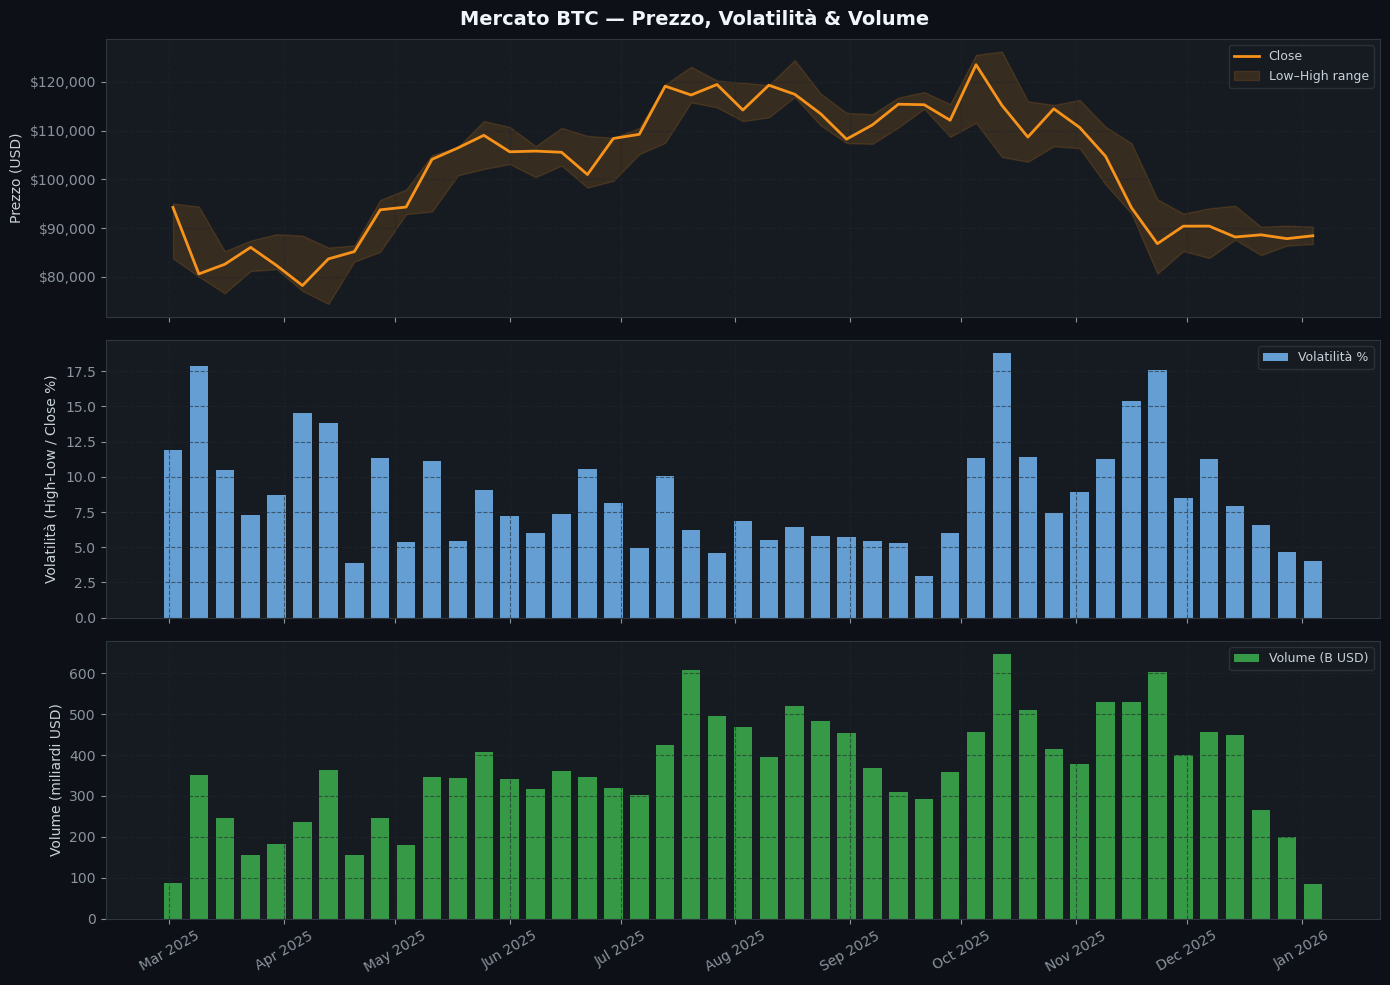

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Mercato BTC — Prezzo, Volatilità & Volume', fontsize=14, fontweight='bold', color='#f0f6fc')

# Prezzo
ax = axes[0]
ax.plot(df_market.index, df_market['Close'], color='#f7931a', linewidth=2, label='Close')
ax.fill_between(df_market.index, df_market['Low'], df_market['High'], color='#f7931a', alpha=0.15, label='Low–High range')
ax.set_ylabel('Prezzo (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=9)
ax.grid(True)

# Volatilità settimanale (High - Low) / Close
volatility = (df_market['High'] - df_market['Low']) / df_market['Close'] * 100
ax2 = axes[1]
ax2.bar(df_market.index, volatility, color='#79c0ff', alpha=0.8, width=5, label='Volatilità %')
ax2.set_ylabel('Volatilità (High-Low / Close %)')
ax2.legend(fontsize=9)
ax2.grid(True)

# Volume
ax3 = axes[2]
ax3.bar(df_market.index, df_market['Volume'] / 1e9, color='#3fb950', alpha=0.8, width=5, label='Volume (B USD)')
ax3.set_ylabel('Volume (miliardi USD)')
ax3.legend(fontsize=9)
ax3.grid(True)
ax3.xaxis.set_major_formatter(FMT)
ax3.xaxis.set_major_locator(LOC)
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig('./data/eda_mercato.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Mining — Hash Rate & Difficulty vs Prezzo

In [5]:
print('=== STATISTICHE DESCRITTIVE: MINING ===')
print(df_mining.describe().to_string())

=== STATISTICHE DESCRITTIVE: MINING ===
          hash_rate    difficulty
count  4.300000e+01  4.300000e+01
mean   9.725607e+08  1.322054e+14
std    1.218522e+08  1.414498e+13
min    7.777387e+08  1.105684e+14
25%    8.988445e+08  1.215831e+14
50%    9.342239e+08  1.276201e+14
75%    1.063448e+09  1.482111e+14
max    1.240554e+09  1.559730e+14


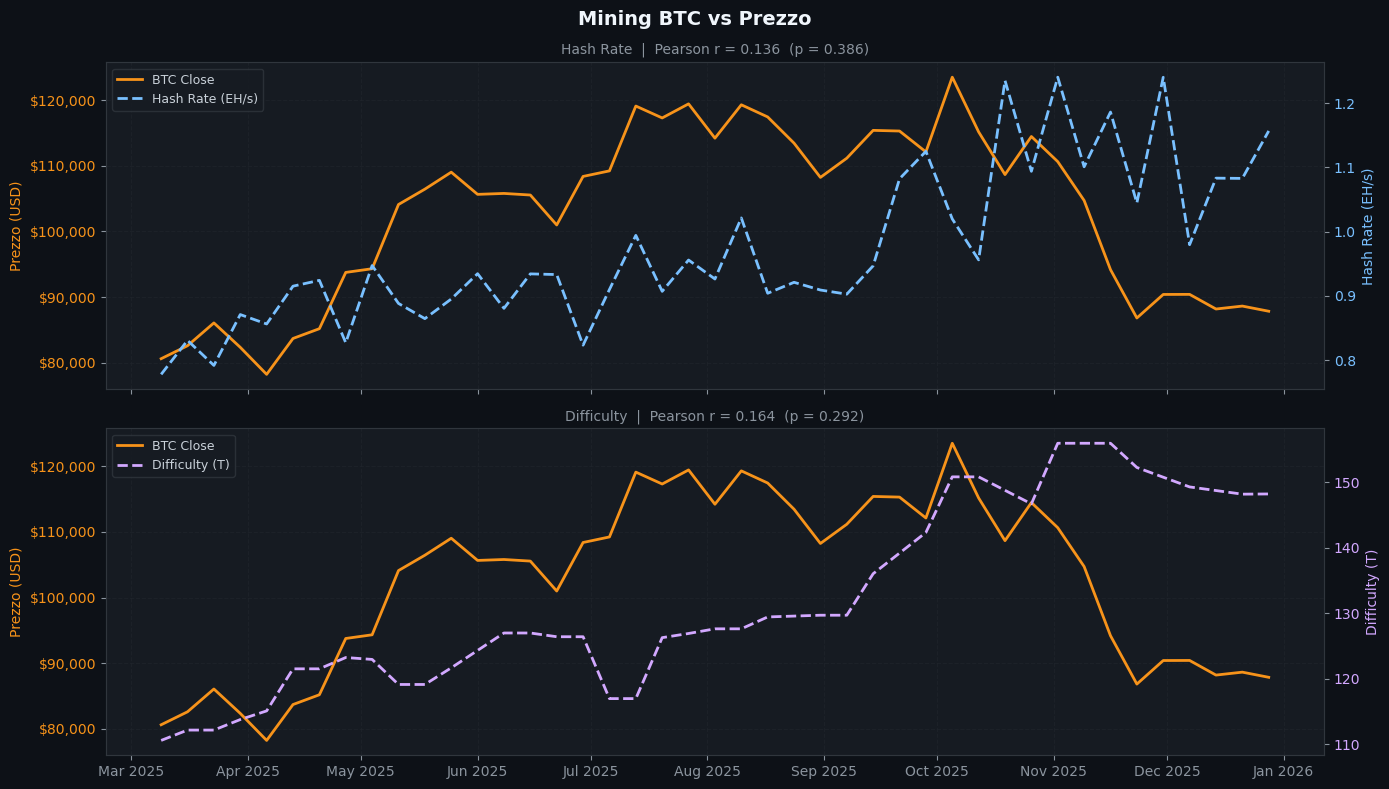


Correlazione Hash Rate  vs Close: r = 0.136
Correlazione Difficulty vs Close: r = 0.164


In [6]:
combo_mining = price.join(df_mining, how='inner')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Mining BTC vs Prezzo', fontsize=14, fontweight='bold', color='#f0f6fc')

# Hash Rate
ax1 = axes[0]
ax2 = ax1.twinx()
ax1.plot(combo_mining.index, combo_mining['Close'], color='#f7931a', linewidth=2, label='BTC Close')
ax2.plot(combo_mining.index, combo_mining['hash_rate'] / 1e9, color='#79c0ff', linewidth=2, linestyle='--', label='Hash Rate (EH/s)')
ax1.set_ylabel('Prezzo (USD)', color='#f7931a')
ax2.set_ylabel('Hash Rate (EH/s)', color='#79c0ff')
ax1.tick_params(axis='y', labelcolor='#f7931a')
ax2.tick_params(axis='y', labelcolor='#79c0ff')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=9, loc='upper left')
r, p = stats.pearsonr(combo_mining['hash_rate'], combo_mining['Close'])
ax1.set_title(f'Hash Rate  |  Pearson r = {r:.3f}  (p = {p:.3f})', fontsize=10, color='#8b949e')
ax1.grid(True)

# Difficulty
ax3 = axes[1]
ax4 = ax3.twinx()
ax3.plot(combo_mining.index, combo_mining['Close'], color='#f7931a', linewidth=2, label='BTC Close')
ax4.plot(combo_mining.index, combo_mining['difficulty'] / 1e12, color='#d2a8ff', linewidth=2, linestyle='--', label='Difficulty (T)')
ax3.set_ylabel('Prezzo (USD)', color='#f7931a')
ax4.set_ylabel('Difficulty (T)', color='#d2a8ff')
ax3.tick_params(axis='y', labelcolor='#f7931a')
ax4.tick_params(axis='y', labelcolor='#d2a8ff')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax3.legend(lines3+lines4, labels3+labels4, fontsize=9, loc='upper left')
r2, p2 = stats.pearsonr(combo_mining['difficulty'], combo_mining['Close'])
ax3.set_title(f'Difficulty  |  Pearson r = {r2:.3f}  (p = {p2:.3f})', fontsize=10, color='#8b949e')
ax3.grid(True)
ax3.xaxis.set_major_formatter(FMT)
ax3.xaxis.set_major_locator(LOC)
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig('./data/eda_mining.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nCorrelazione Hash Rate  vs Close: r = {r:.3f}')
print(f'Correlazione Difficulty vs Close: r = {r2:.3f}')

---
## 4. Energia — Costo per BTC vs Prezzo

In [7]:
print('=== STATISTICHE DESCRITTIVE: ENERGIA ===')
print(df_energy.describe().round(2).to_string())

=== STATISTICHE DESCRITTIVE: ENERGIA ===
       hash_rate_ths  power_gw  daily_consumption_gwh  annualised_twh  cost_per_btc_usd
count          43.00     43.00                  43.00           43.00             43.00
mean       972560.72      0.02                   0.47            0.17             50.20
std        121852.15      0.00                   0.06            0.02              6.29
min        777738.67      0.02                   0.37            0.14             40.14
25%        898844.51      0.02                   0.43            0.16             46.39
50%        934223.90      0.02                   0.45            0.16             48.22
75%       1063448.14      0.02                   0.51            0.19             54.89
max       1240553.84      0.02                   0.60            0.22             64.03


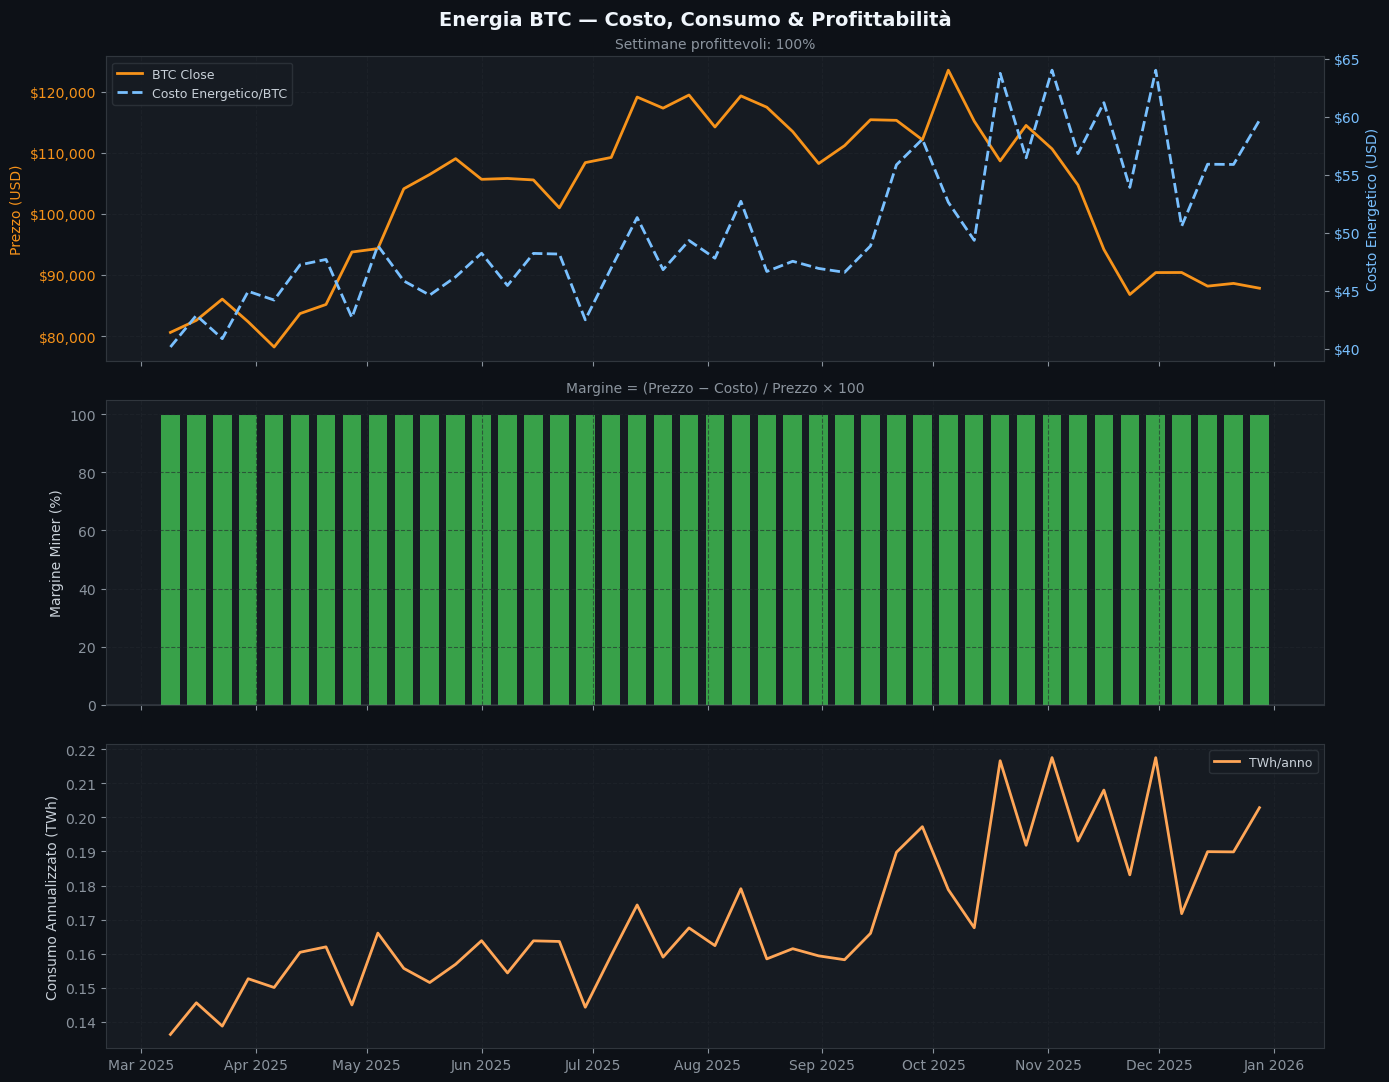

In [8]:
combo_energy = price.join(df_energy, how='inner')

# Margine di profitto del miner
combo_energy['profit_margin'] = (combo_energy['Close'] - combo_energy['cost_per_btc_usd']) / combo_energy['Close'] * 100
profitable_pct = (combo_energy['Close'] > combo_energy['cost_per_btc_usd']).mean() * 100

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle('Energia BTC — Costo, Consumo & Profittabilità', fontsize=14, fontweight='bold', color='#f0f6fc')

# Prezzo vs costo energetico
ax1 = axes[0]
ax2 = ax1.twinx()
ax1.plot(combo_energy.index, combo_energy['Close'], color='#f7931a', linewidth=2, label='BTC Close')
ax2.plot(combo_energy.index, combo_energy['cost_per_btc_usd'], color='#79c0ff', linewidth=2, linestyle='--', label='Costo Energetico/BTC')
ax1.set_ylabel('Prezzo (USD)', color='#f7931a')
ax2.set_ylabel('Costo Energetico (USD)', color='#79c0ff')
ax1.tick_params(axis='y', labelcolor='#f7931a')
ax2.tick_params(axis='y', labelcolor='#79c0ff')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=9, loc='upper left')
ax1.set_title(f'Settimane profittevoli: {profitable_pct:.0f}%', fontsize=10, color='#8b949e')
ax1.grid(True)

# Margine miner %
colors = ['#3fb950' if v >= 0 else '#f85149' for v in combo_energy['profit_margin']]
axes[1].bar(combo_energy.index, combo_energy['profit_margin'], color=colors, alpha=0.85, width=5)
axes[1].axhline(0, color='#8b949e', linewidth=1)
axes[1].set_ylabel('Margine Miner (%)')
axes[1].set_title('Margine = (Prezzo − Costo) / Prezzo × 100', fontsize=10, color='#8b949e')
axes[1].grid(True)

# Consumo annualizzato
axes[2].plot(combo_energy.index, combo_energy['annualised_twh'], color='#ffa657', linewidth=2, label='TWh/anno')
axes[2].set_ylabel('Consumo Annualizzato (TWh)')
axes[2].legend(fontsize=9)
axes[2].grid(True)
axes[2].xaxis.set_major_formatter(FMT)
axes[2].xaxis.set_major_locator(LOC)
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig('./data/eda_energia.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Sentiment — Social vs Prezzo

In [9]:
print('=== STATISTICHE DESCRITTIVE: SENTIMENT ===')
print(df_sentiment.describe().round(3).to_string())

=== STATISTICHE DESCRITTIVE: SENTIMENT ===
       sentiment_score_mean  sentiment_score_weighted  positive_pct  negative_pct  tweet_count
count                40.000                    44.000        40.000        40.000       44.000
mean                  0.204                     0.178        56.143        19.371      191.705
std                   0.117                     0.123        12.338        11.478      132.632
min                  -0.114                    -0.107        24.074         0.000        0.000
25%                   0.131                     0.129        49.860        11.836       83.750
50%                   0.219                     0.194        56.406        16.805      182.000
75%                   0.285                     0.259        67.088        25.044      286.750
max                   0.388                     0.384        79.464        51.149      495.000


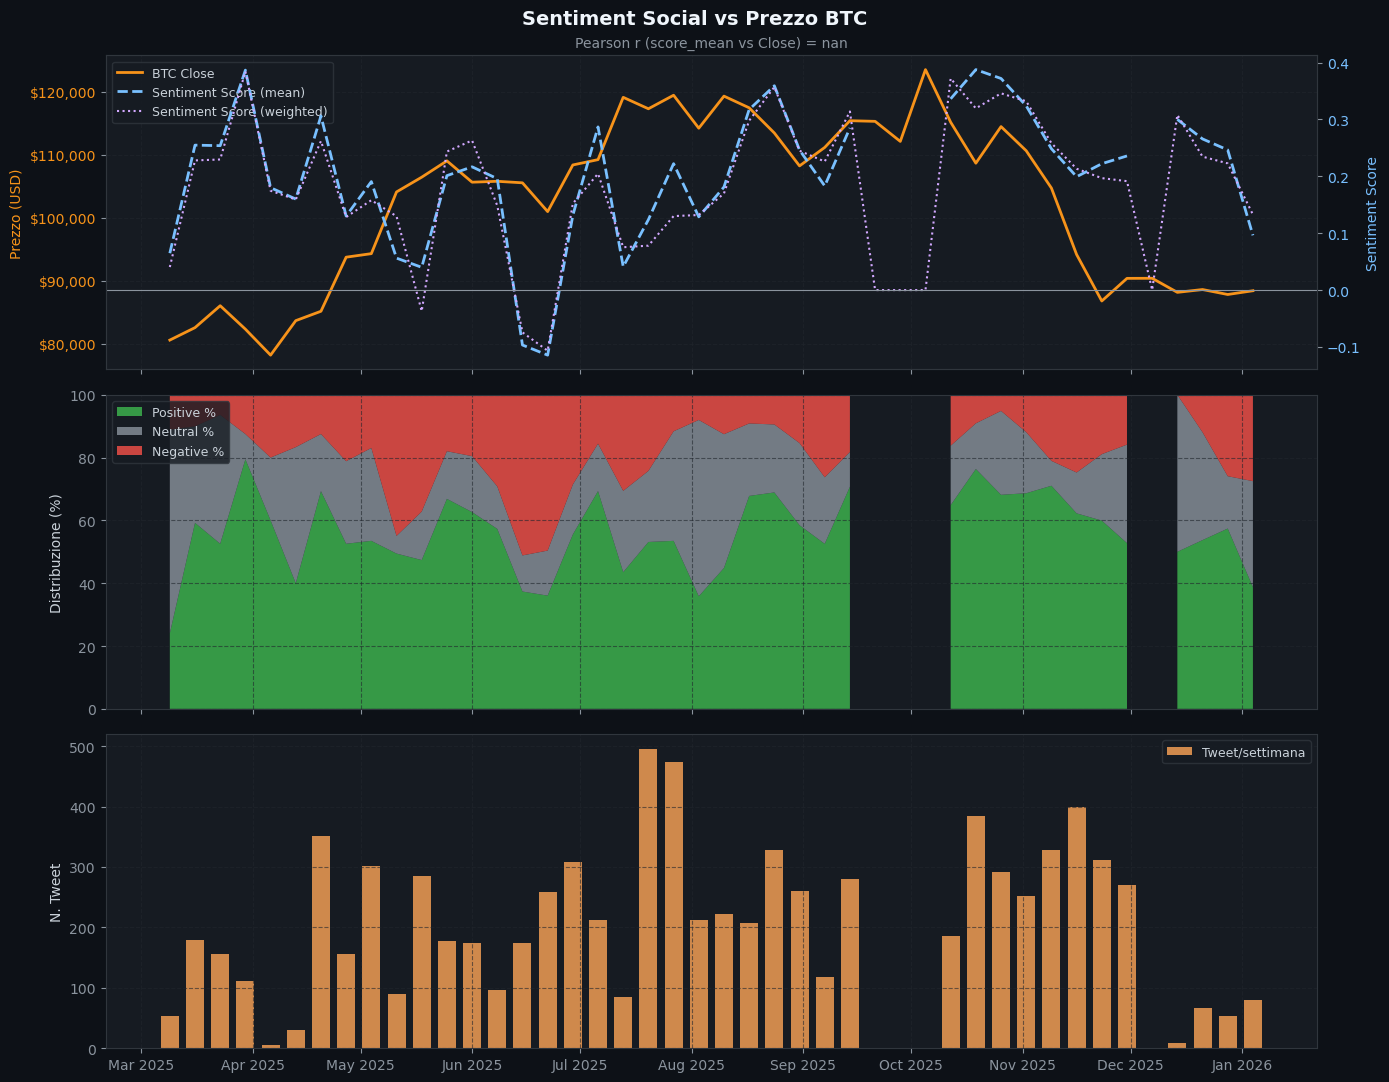

In [10]:
combo_sent = price.join(df_sentiment, how='inner')

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle('Sentiment Social vs Prezzo BTC', fontsize=14, fontweight='bold', color='#f0f6fc')

# Prezzo vs sentiment score
ax1 = axes[0]
ax2 = ax1.twinx()
ax1.plot(combo_sent.index, combo_sent['Close'], color='#f7931a', linewidth=2, label='BTC Close')
ax2.plot(combo_sent.index, combo_sent['sentiment_score_mean'], color='#79c0ff', linewidth=2, linestyle='--', label='Sentiment Score (mean)')
ax2.plot(combo_sent.index, combo_sent['sentiment_score_weighted'], color='#d2a8ff', linewidth=1.5, linestyle=':', label='Sentiment Score (weighted)')
ax2.axhline(0, color='#8b949e', linewidth=0.8, linestyle='-')
ax1.set_ylabel('Prezzo (USD)', color='#f7931a')
ax2.set_ylabel('Sentiment Score', color='#79c0ff')
ax1.tick_params(axis='y', labelcolor='#f7931a')
ax2.tick_params(axis='y', labelcolor='#79c0ff')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=9, loc='upper left')
r_sent, _ = stats.pearsonr(combo_sent['sentiment_score_mean'], combo_sent['Close'])
ax1.set_title(f'Pearson r (score_mean vs Close) = {r_sent:.3f}', fontsize=10, color='#8b949e')
ax1.grid(True)

# Distribuzione label %
axes[1].stackplot(
    combo_sent.index,
    combo_sent['positive_pct'],
    100 - combo_sent['positive_pct'] - combo_sent['negative_pct'],
    combo_sent['negative_pct'],
    labels=['Positive %', 'Neutral %', 'Negative %'],
    colors=['#3fb950', '#8b949e', '#f85149'],
    alpha=0.8
)
axes[1].set_ylabel('Distribuzione (%)')
axes[1].set_ylim(0, 100)
axes[1].legend(fontsize=9, loc='upper left')
axes[1].grid(True)

# Volume tweet
axes[2].bar(combo_sent.index, combo_sent['tweet_count'], color='#ffa657', alpha=0.8, width=5, label='Tweet/settimana')
axes[2].set_ylabel('N. Tweet')
axes[2].legend(fontsize=9)
axes[2].grid(True)
axes[2].xaxis.set_major_formatter(FMT)
axes[2].xaxis.set_major_locator(LOC)
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig('./data/eda_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Matrice di correlazione globale

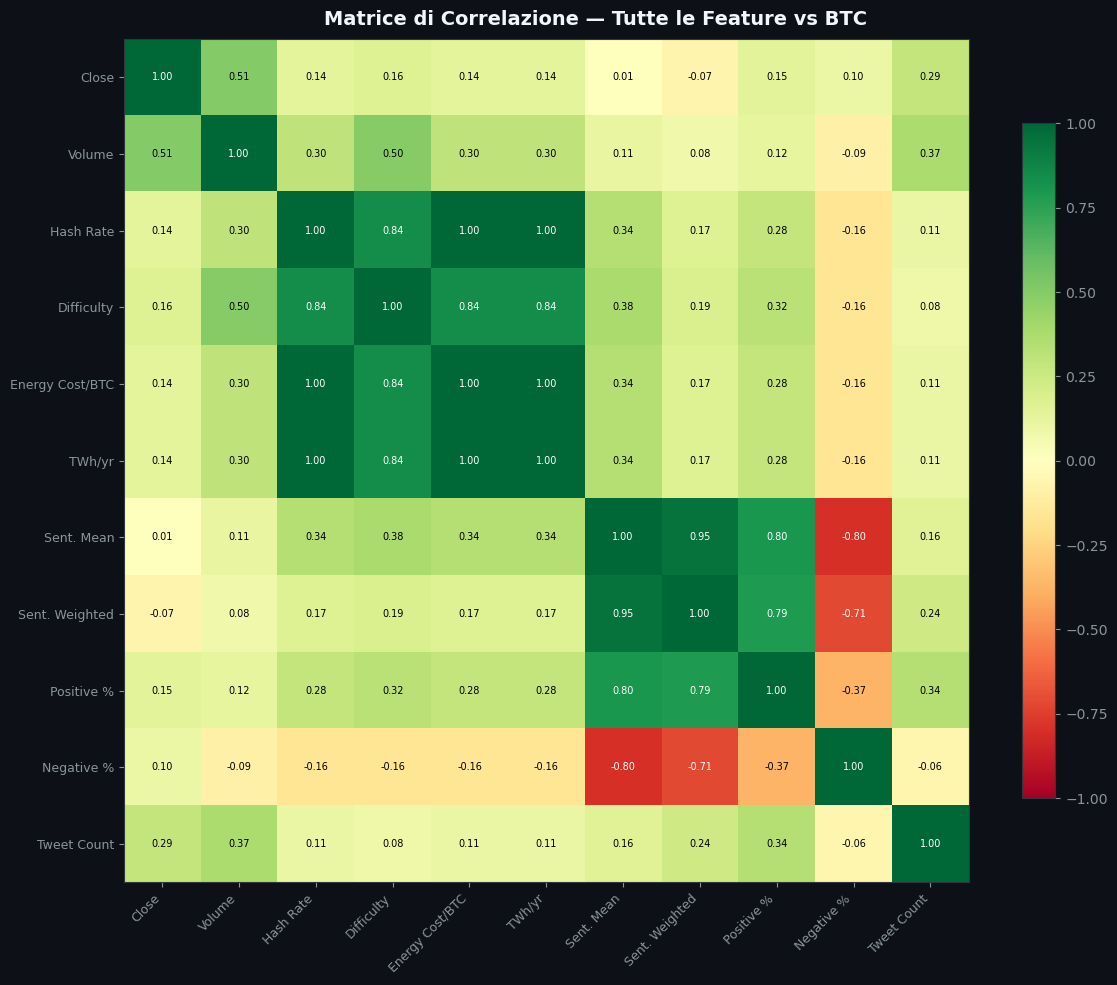


=== CORRELAZIONE CON CLOSE PRICE ===
Volume                      0.507
tweet_count                 0.285
difficulty                  0.164
positive_pct                0.147
cost_per_btc_usd            0.136
hash_rate                   0.136
annualised_twh              0.136
negative_pct                0.099
sentiment_score_mean        0.005
sentiment_score_weighted   -0.067


In [11]:
# Unisci tutti i dataset
df_all = price.join(df_mining, how='outer') \
              .join(df_energy[['cost_per_btc_usd', 'annualised_twh']], how='outer') \
              .join(df_sentiment[['sentiment_score_mean', 'sentiment_score_weighted', 'positive_pct', 'negative_pct', 'tweet_count']], how='outer')

cols_interest = [
    'Close', 'Volume',
    'hash_rate', 'difficulty',
    'cost_per_btc_usd', 'annualised_twh',
    'sentiment_score_mean', 'sentiment_score_weighted',
    'positive_pct', 'negative_pct', 'tweet_count'
]
corr = df_all[cols_interest].corr()

fig, ax = plt.subplots(figsize=(12, 10))
fig.suptitle('Matrice di Correlazione — Tutte le Feature vs BTC', fontsize=14, fontweight='bold', color='#f0f6fc')

im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)

labels = [
    'Close', 'Volume',
    'Hash Rate', 'Difficulty',
    'Energy Cost/BTC', 'TWh/yr',
    'Sent. Mean', 'Sent. Weighted',
    'Positive %', 'Negative %', 'Tweet Count'
]
ax.set_xticks(range(len(cols_interest)))
ax.set_yticks(range(len(cols_interest)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(labels, fontsize=9)

# Valori nelle celle
for i in range(len(cols_interest)):
    for j in range(len(cols_interest)):
        val = corr.iloc[i, j]
        color = 'black' if abs(val) < 0.6 else 'white'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=color)

plt.tight_layout()
plt.savefig('./data/eda_correlazione.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== CORRELAZIONE CON CLOSE PRICE ===')
print(corr['Close'].drop('Close').sort_values(ascending=False).round(3).to_string())

---
## 7. Lag Analysis — Sentiment anticipa il prezzo?

 lag_weeks  pearson_r  p_value
        -4        NaN      NaN
        -3        NaN      NaN
        -2        NaN      NaN
        -1        NaN      NaN
         0   0.005418  0.97353
         1        NaN      NaN
         2        NaN      NaN
         3        NaN      NaN
         4        NaN      NaN


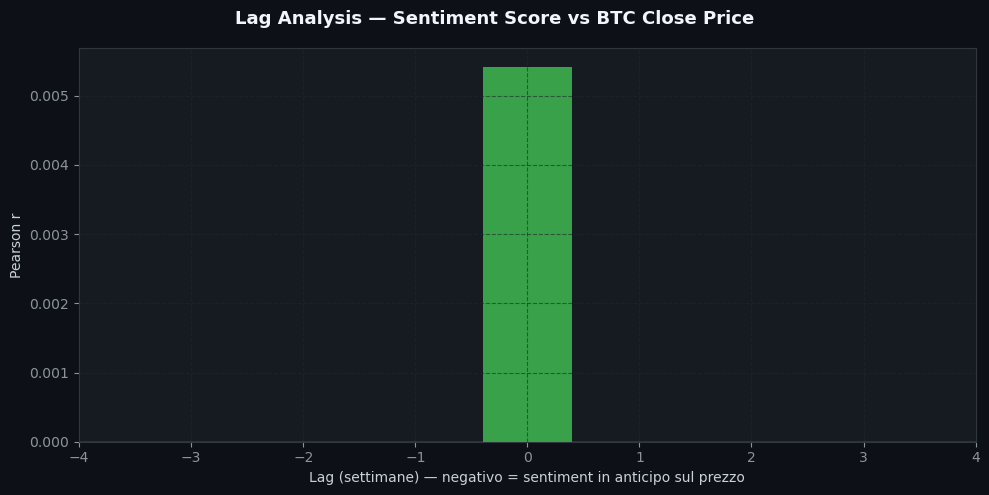

In [12]:
combo_lag = price[['Close']].join(df_sentiment[['sentiment_score_mean']], how='inner').dropna()

lags = range(-4, 5)  # -4 settimane (sentiment in anticipo) → +4 (in ritardo)
correlations = []
for lag in lags:
    shifted = combo_lag['sentiment_score_mean'].shift(lag)
    r, p = stats.pearsonr(
        combo_lag['Close'].dropna(),
        shifted.dropna().reindex(combo_lag['Close'].dropna().index)
    )
    correlations.append((lag, r, p))

lag_df = pd.DataFrame(correlations, columns=['lag_weeks', 'pearson_r', 'p_value'])
print(lag_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Lag Analysis — Sentiment Score vs BTC Close Price', fontsize=13, fontweight='bold', color='#f0f6fc')
colors_bar = ['#3fb950' if r >= 0 else '#f85149' for _, r, _ in correlations]
ax.bar(lag_df['lag_weeks'], lag_df['pearson_r'], color=colors_bar, alpha=0.85)
ax.axhline(0, color='#8b949e', linewidth=1)
ax.set_xlabel('Lag (settimane) — negativo = sentiment in anticipo sul prezzo')
ax.set_ylabel('Pearson r')
ax.set_xticks(list(lags))
ax.grid(True)
plt.tight_layout()
plt.savefig('./data/eda_lag.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Riepilogo statistico globale

In [13]:
print('=' * 55)
print('RIEPILOGO — CORRELAZIONI CON BTC CLOSE PRICE')
print('=' * 55)

features = {
    'Hash Rate':              ('df_mining',    'hash_rate'),
    'Difficulty':             ('df_mining',    'difficulty'),
    'Energy Cost/BTC':        ('df_energy',    'cost_per_btc_usd'),
    'TWh annualizzati':       ('df_energy',    'annualised_twh'),
    'Sentiment Mean':         ('df_sentiment', 'sentiment_score_mean'),
    'Sentiment Weighted':     ('df_sentiment', 'sentiment_score_weighted'),
    'Positive %':             ('df_sentiment', 'positive_pct'),
    'Negative %':             ('df_sentiment', 'negative_pct'),
    'Volume':                 ('df_market',    'Volume'),
}

src_map = {
    'df_mining':    df_mining,
    'df_energy':    df_energy,
    'df_sentiment': df_sentiment,
    'df_market':    df_market,
}

results = []
for name, (src, col) in features.items():
    joined = price[['Close']].join(src_map[src][[col]], how='inner').dropna()
    if len(joined) > 5:
        r, p = stats.pearsonr(joined[col], joined['Close'])
        results.append({'Feature': name, 'r': round(r, 3), 'p-value': round(p, 4), 'N': len(joined)})

summary = pd.DataFrame(results).sort_values('r', ascending=False, key=abs)
print(summary.to_string(index=False))

RIEPILOGO — CORRELAZIONI CON BTC CLOSE PRICE
           Feature      r  p-value  N
            Volume  0.507   0.0004 45
        Difficulty  0.164   0.2923 43
        Positive %  0.147   0.3640 40
         Hash Rate  0.136   0.3861 43
   Energy Cost/BTC  0.136   0.3861 43
  TWh annualizzati  0.136   0.3861 43
        Negative %  0.099   0.5428 40
Sentiment Weighted -0.067   0.6672 44
    Sentiment Mean  0.005   0.9735 40
